

---



---


# **Klasifikasi Citra Tumor Otak Menggunakan Metode Naive Bayes**

---


---

Pada project ini dilakukan klasifikasi citra tumor otak menggunakan metode Machine Learning yaitu **Naive Bayes**
Dataset yang digunakan berisi fitur-fitur statistik hasil ekstraksi citra seperti Mean, Entropy, Contrast, dan lain-lain. Tujuannya adalah :
- Mengklasifikasikan citra menjadi **tumor (1)** dan **tidak tumor (0)**
- Menganalisis performa model Naive Bayes
- Memahami alur kerja Machine Learning dari preprocessing hingga evaluasi
---



## 1. Import Library


Pada tahap ini dilakukan import library yang dibutuhkan untuk mendukung proses pengolahan data, visualisasi, serta pembuatan model Machine Learning.

Library yang digunakan meliputi:
- **NumPy dan Pandas** untuk pengolahan data
- **Matplotlib dan Seaborn** untuk visualisasi
- **Scikit-learn** untuk pembuatan model Naive Bayes dan evaluasi

Import library merupakan langkah awal yang penting agar seluruh proses analisis dan pemodelan dapat berjalan dengan baik.

In [ ]:
# Library dasar untuk olah data
import numpy as np
import pandas as pd

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")  # biar grafik lebih enak dilihat

# Library machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

# Library evaluasi model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


Library yang telah diimport akan digunakan pada setiap tahap, mulai dari preprocessing, visualisasi, hingga evaluasi model. Penggunaan library yang tepat membantu mempermudah proses analisis serta meningkatkan efisiensi dalam pembuatan model Machine Learning.

---



## 2. Mount Google Drive dan Membaca Data

Pada tahap ini dilakukan proses menghubungkan Google Colab dengan Google Drive menggunakan `drive.mount()`, kemudian membaca dataset yang tersimpan dalam bentuk file CSV menggunakan library pandas.

Dataset yang digunakan berisi fitur-fitur hasil ekstraksi citra tumor otak. Setelah dataset berhasil dimuat, ditampilkan beberapa data awal untuk memastikan bahwa data telah terbaca dengan benar.

In [ ]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Membaca dataset
data_path = "/content/drive/MyDrive/Computer Vision/Brain Tumor.csv"
df = pd.read_csv(data_path)

In [ ]:
# Menampilkan 5 data pertama untuk memastikan dataset berhasil dibaca
print("=== DATASET (5 DATA TERATAS) ===")
display(df.head())

=== DATASET (5 DATA TERATAS) ===


,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


Setelah proses mount berhasil, dan dataset dapat diakses. Data yang ditampilkan merupakan sebagian kecil dari dataset yang digunakan untuk pengecekan awal sebelum dilakukan proses analisis lebih lanjut.

---



## 3. Data Understanding
Pada tahap ini dilakukan eksplorasi awal terhadap dataset untuk memahami struktur dan karakteristik data. Proses ini meliputi pengecekan informasi dataset, tipe data pada setiap kolom, serta analisis statistik deskriptif.

Tujuannya adalah untuk memastikan data dalam kondisi baik dan memahami pola dasar sebelum dilakukan tahap preprocessing dan pemodelan.

In [ ]:
# Menampilkan informasi dataset (jumlah data, tipe data, dll)
print("\n=== INFO DATASET ===")
print(df.info())


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(

In [ ]:
# Mengecek apakah ada data kosong (missing value)
print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())


=== CEK MISSING VALUE ===
Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


In [ ]:
# Menampilkan statistik deskriptif (mean, std, dll)
print("\n=== DESKRIPSI STATISTIK ===")
display(df.describe())


=== DESKRIPSI STATISTIK ===


,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
count,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3.762000e+03
mean,0.447368,9.488890,711.101063,25.182271,0.073603,4.102727,24.389071,127.961459,0.204705,0.058632,0.479252,4.698498,0.955767,7.458341e-155
std,0.497288,5.728022,467.466896,8.773526,0.070269,2.560940,56.434747,109.499601,0.129352,0.058300,0.127929,1.850173,0.026157,0.000000e+00
min,0.000000,0.078659,3.145628,1.773592,0.000882,1.886014,3.942402,3.194733,0.024731,0.000612,0.105490,0.681121,0.549426,7.458341e-155
25%,0.000000,4.982395,363.225459,19.058475,0.006856,2.620203,7.252852,72.125208,0.069617,0.004847,0.364973,3.412363,0.947138,7.458341e-155
50%,0.000000,8.477531,622.580417,24.951560,0.066628,3.422210,12.359088,106.737418,0.225496,0.050849,0.512551,4.482404,0.961610,7.458341e-155
75%,1.000000,13.212723,966.954319,31.095889,0.113284,4.651737,22.640304,161.059006,0.298901,0.089342,0.575557,5.723821,0.971355,7.458341e-155
max,1.000000,33.239975,2910.581879,53.949809,0.394539,36.931294,1371.640060,3382.574163,0.589682,0.347725,0.810921,27.827751,0.989972,7.458341e-155


#### Analisis Data :

Berdasarkan hasil yang ditampilkan, dataset terdiri dari sejumlah fitur numerik yang merepresentasikan karakteristik citra, serta satu variabel target yaitu *Class* yang menunjukkan kategori tumor dan tidak tumor.

Tidak ditemukan nilai kosong pada dataset, sehingga data dapat langsung digunakan pada tahap selanjutnya. Statistik deskriptif menunjukkan variasi nilai pada setiap fitur yang nantinya akan dinormalisasi agar memiliki skala yang seimbang.

---



## 4. Preprocessing Data
Pada tahap ini dilakukan proses persiapan data sebelum digunakan dalam model Machine Learning. Tahapan ini sangat penting karena kualitas data akan sangat mempengaruhi hasil model.

Proses preprocessing meliputi penghapusan kolom yang tidak diperlukan, pengecekan data duplikat, pemisahan fitur dan target, serta normalisasi data agar memiliki skala yang seimbang.

a. Menghapus Kolom yang Tidak Digunakan


In [ ]:
# Kolom 'Image' hanya sebagai identifier, tidak berpengaruh ke model
df_clean = df.drop(['Image'], axis=1)

print("Kolom setelah drop:", df_clean.columns)

Kolom setelah drop: Index(['Class', 'Mean', 'Variance', 'Standard Deviation', 'Entropy',
       'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity',
       'Dissimilarity', 'Correlation', 'Coarseness'],
      dtype='object')


b. Mengecek dan Menghapus Data Duplikat

In [ ]:
# Duplikat bisa mengganggu performa model
duplicate_count = df_clean.duplicated().sum()
print("\nJumlah data duplikat:", duplicate_count)

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplikat sudah dihapus")


Jumlah data duplikat: 63
Duplikat sudah dihapus


c. Memisahkan Fitur (X) dan Target (y)

In [ ]:
## X = semua kolom kecuali Class
# y = label (0 = tidak tumor, 1 = tumor)

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

print("\nJumlah fitur:", X.shape)
print("Jumlah target:", y.shape)


Jumlah fitur: (3699, 13)
Jumlah target: (3699,)


d. Mengecek Fitur yang Nilainya Konstan (Tidak Berubah)

In [ ]:
# Fitur seperti ini tidak berguna untuk model
constant_features = [col for col in X.columns if X[col].nunique() == 1]
print("\nFitur konstan:", constant_features)

# Jika ada fitur konstan, maka akan dihapus
if len(constant_features) > 0:
    X = X.drop(columns=constant_features)
    print("Fitur konstan dihapus")


Fitur konstan: []


e. Melakukan Scaling Data

In [ ]:
# Scaling penting agar semua fitur punya skala yang seimbang
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Transformasi data
X_scaled = scaler.fit_transform(X)

# Mengubah kembali ke DataFrame agar tetap rapi
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nData setelah scaling:")
display(X_scaled.head())


Data setelah scaling:


,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,-0.512570,-0.195065,-0.032174,0.516683,0.065700,-0.098107,-0.267861,0.695716,0.482246,0.410303,-0.123586,1.007070,-1.142698e-168
1,-0.126203,0.203084,0.366036,2.769449,-0.152510,-0.176920,-0.583378,2.104206,2.891273,1.351356,-0.798682,1.271700,-1.142698e-168
2,-0.371997,0.924847,0.984301,-1.022441,0.372590,0.036546,-0.419893,-1.330158,-0.984399,-1.642526,0.688968,0.856443,-1.142698e-168
3,-0.613268,0.531555,0.660870,-1.022293,0.613415,0.160012,0.209799,-1.329329,-0.984281,-1.833407,1.614999,0.325911,-1.142698e-168
4,-0.376509,0.039832,0.209002,1.056010,0.068336,-0.094935,0.425489,1.087370,1.037732,0.177393,1.148390,0.655929,-1.142698e-168


f. Cek Ulang Statistik Setelah Scaling

In [ ]:
print("\nStatistik setelah scaling:")
display(X_scaled.describe())


Statistik setelah scaling:


,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
count,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03,3.699000e+03
mean,3.342375e-16,9.988706e-17,-9.220344e-17,-1.536724e-17,-1.075707e-16,3.841810e-17,-6.531077e-17,1.383052e-16,-3.073448e-17,3.227120e-16,-1.997741e-16,1.828701e-15,-1.060852e-170
std,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,0.000000e+00
min,-1.639012e+00,-1.511993e+00,-2.663998e+00,-1.030812e+00,-8.685057e-01,-3.638648e-01,-1.134102e+00,-1.385847e+00,-9.914214e-01,-2.914748e+00,-2.166329e+00,-1.559110e+01,-1.142698e-168
25%,-7.863616e-01,-7.441445e-01,-6.981910e-01,-9.481286e-01,-5.810945e-01,-3.048205e-01,-5.089452e-01,-1.044362e+00,-9.203300e-01,-8.922160e-01,-6.946147e-01,-3.384063e-01,-1.142698e-168
50%,-1.753232e-01,-1.841260e-01,-2.048924e-02,-1.038515e-01,-2.679897e-01,-2.141282e-01,-1.910488e-01,1.544996e-01,-1.403564e-01,2.614452e-01,-1.167093e-01,2.252774e-01,-1.142698e-168
75%,6.474669e-01,5.472023e-01,6.743024e-01,5.686841e-01,2.167327e-01,-2.952498e-02,3.003030e-01,7.328838e-01,5.311764e-01,7.565050e-01,5.509855e-01,5.993682e-01,-1.142698e-168
max,4.146359e+00,4.699270e+00,3.275921e+00,4.600514e+00,1.282738e+01,2.393562e+01,2.954479e+01,2.992611e+00,4.996854e+00,2.598442e+00,1.245665e+01,1.315370e+00,1.345569e-167


g. Final Check Sebelum Masuk Model

In [ ]:
print("\n=== FINAL CHECK ===")
print("Jumlah data:", X_scaled.shape)
print("Jumlah label:", y.shape)


=== FINAL CHECK ===
Jumlah data: (3699, 13)
Jumlah label: (3699,)


#### Analisis Hasil Preprocessing :

Setelah dilakukan preprocessing, data telah bersih dan siap digunakan untuk proses pemodelan. Kolom yang tidak relevan telah dihapus, serta tidak ditemukan data duplikat yang dapat mengganggu proses training.

Fitur dan target telah dipisahkan dengan jelas, dan seluruh fitur numerik telah dinormalisasi menggunakan StandardScaler sehingga memiliki skala yang seragam. Hal ini membantu model dalam mempelajari pola data dengan lebih optimal.

---



## 5. Visualisasi Data (EDA - Exploratory Data Analysis)
Pada tahap ini dilakukan analisis visual untuk memahami distribusi data, hubungan antar fitur, serta perbedaan antara kelas tumor dan tidak tumor. Visualisasi ini membantu dalam mengidentifikasi pola penting yang akan digunakan dalam proses pemodelan.

In [ ]:
# Menggunakan style biar grafik lebih enak dilihat
sns.set(style="darkgrid")

#### a. Distribusi Target (Class)

* Grafik ini menunjukkan jumlah data pada
masing-masing kelas, yaitu tumor (1) dan tidak tumor (0). Visualisasi ini digunakan untuk mengetahui apakah dataset seimbang atau tidak.
* Berdasarkan grafik, dapat dilihat perbandingan jumlah data antara kedua kelas. Informasi ini penting karena distribusi data yang tidak seimbang dapat mempengaruhi performa model.





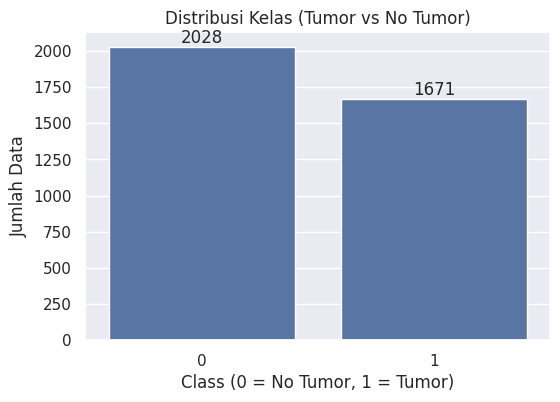

Jumlah Tumor: 1671
Persentase Tumor: 45.17 %
Jumlah No Tumor: 2028
Persentase No Tumor: 54.83 %


In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)

# Menambahkan angka di atas bar biar lebih informatif
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title("Distribusi Kelas (Tumor vs No Tumor)")
plt.xlabel("Class (0 = No Tumor, 1 = Tumor)")
plt.ylabel("Jumlah Data")

plt.show()

# Menampilkan persentase
print("Jumlah Tumor:", y.value_counts()[1])
print("Persentase Tumor:", round(y.value_counts()[1]/len(y)*100,2), "%")

print("Jumlah No Tumor:", y.value_counts()[0])
print("Persentase No Tumor:", round(y.value_counts()[0]/len(y)*100,2), "%")


#### b. Heatmap Korelasi Antar Fitur
* Heatmap digunakan untuk melihat hubungan (korelasi) antar fitur dalam dataset. Nilai korelasi berkisar antara -1 hingga 1, dimana semakin mendekati 1 atau -1 menunjukkan hubungan yang kuat.

* Dari grafik ini, dapat dianalisis fitur mana yang saling berhubungan dan berpotensi mempengaruhi model. Fitur dengan korelasi tinggi dapat memberikan informasi penting dalam proses klasifikasi.

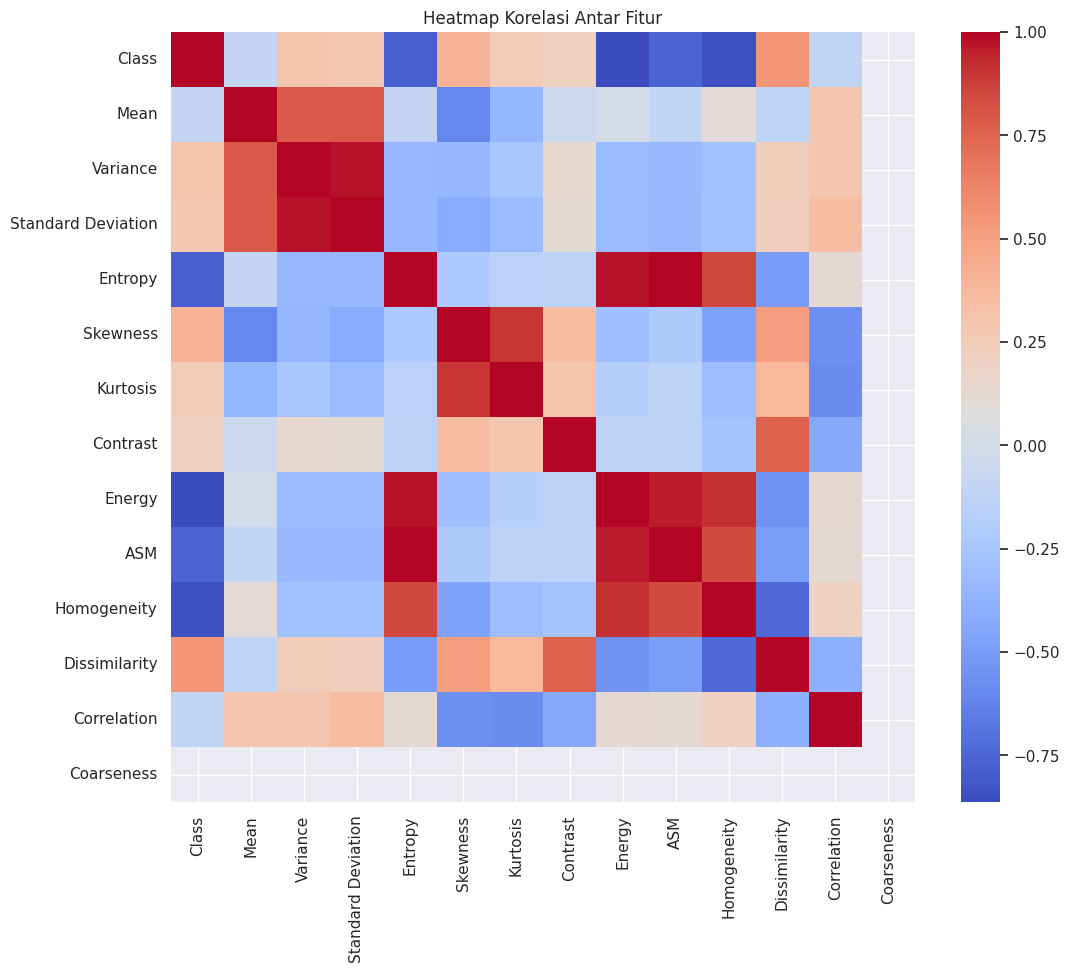

In [ ]:
plt.figure(figsize=(12,10))
correlation = df_clean.corr()
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

#### c. Hubungan Mean dan Entropy
* Scatter plot ini digunakan untuk melihat hubungan antara fitur Mean dan Entropy serta distribusinya terhadap kelas.

* Dari grafik terlihat bahwa terdapat perbedaan pola antara data tumor dan tidak tumor. Hal ini menunjukkan bahwa kedua fitur ini memiliki potensi dalam membedakan kelas.

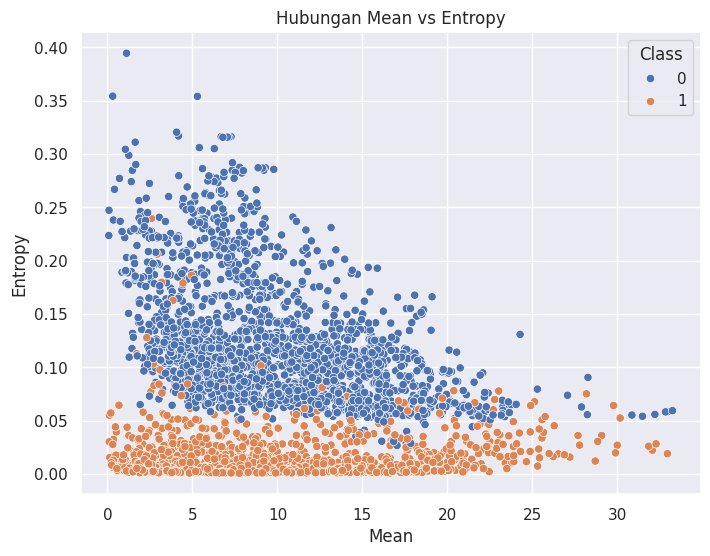

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_clean['Mean'],
    y=df_clean['Entropy'],
    hue=df_clean['Class']
)

plt.title("Hubungan Mean vs Entropy")
plt.xlabel("Mean")
plt.ylabel("Entropy")

plt.show()

#### d. Distribusi Fitur Berdasarkan Class
* Histogram digunakan untuk melihat distribusi nilai fitur pada masing-masing kelas, sedangkan KDE (Kernel Density Estimation) membantu memperhalus distribusi tersebut.

* Dari grafik ini dapat dilihat perbedaan pola distribusi antara kelas tumor dan tidak tumor. Fitur yang memiliki distribusi berbeda antar kelas dapat menjadi indikator yang baik dalam proses klasifikasi.

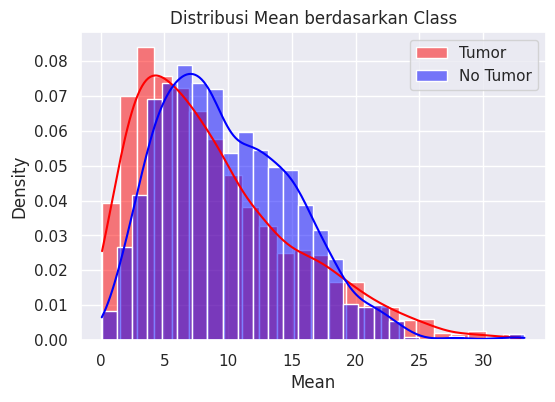

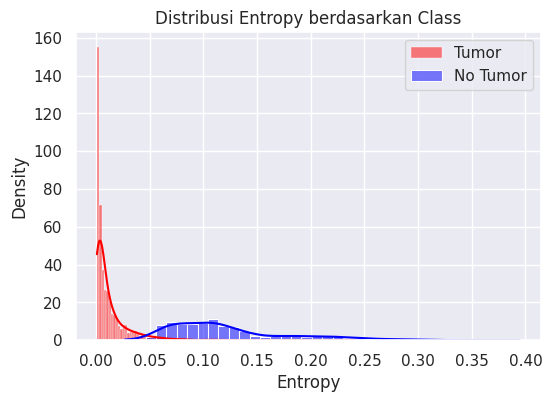

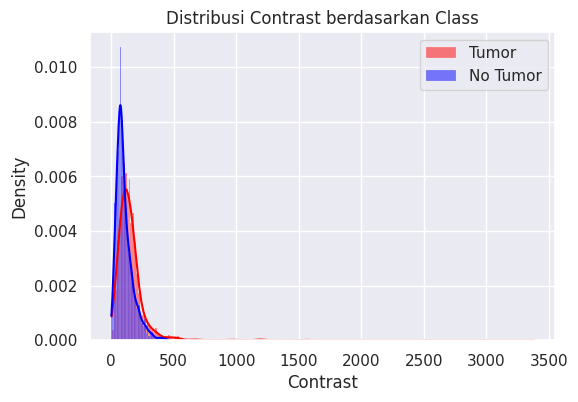

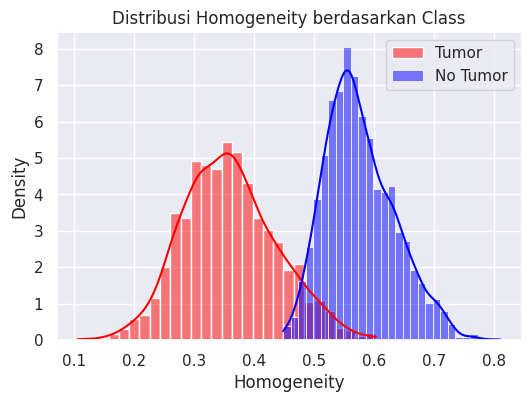

In [ ]:
# Pilih beberapa fitur penting
features = ['Mean', 'Entropy', 'Contrast', 'Homogeneity']

for feature in features:
    plt.figure(figsize=(6,4))

    sns.histplot(df_clean[df_clean['Class']==1][feature],
                 color='red', label='Tumor', kde=True, stat="density", alpha=0.5)

    sns.histplot(df_clean[df_clean['Class']==0][feature],
                 color='blue', label='No Tumor', kde=True, stat="density", alpha=0.5)

    plt.title(f"Distribusi {feature} berdasarkan Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()

    plt.show()

#### e. Boxplot (Analisis Outlier)
* Boxplot digunakan untuk melihat sebaran data serta mendeteksi adanya outlier pada masing-masing fitur berdasarkan kelas.

* Dari grafik ini dapat diamati perbedaan median, rentang data, serta keberadaan outlier. Perbedaan ini menunjukkan bahwa fitur tersebut memiliki karakteristik yang berbeda pada setiap kelas.

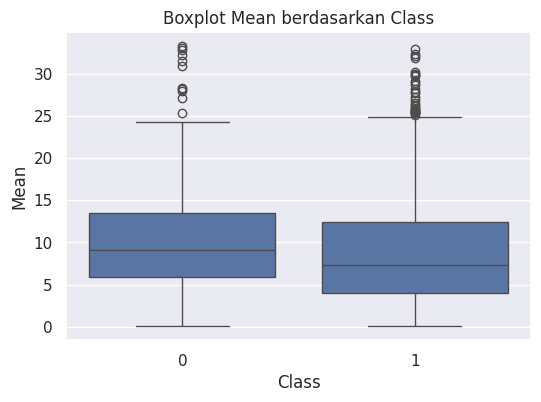

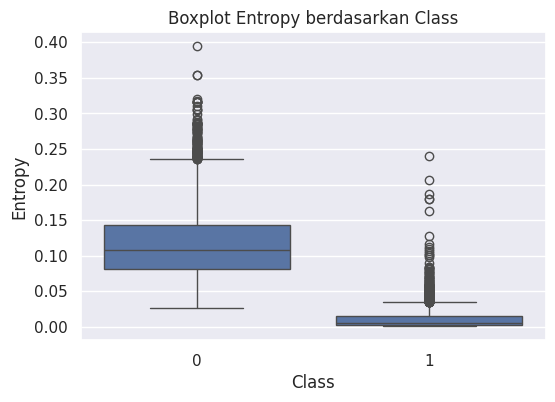

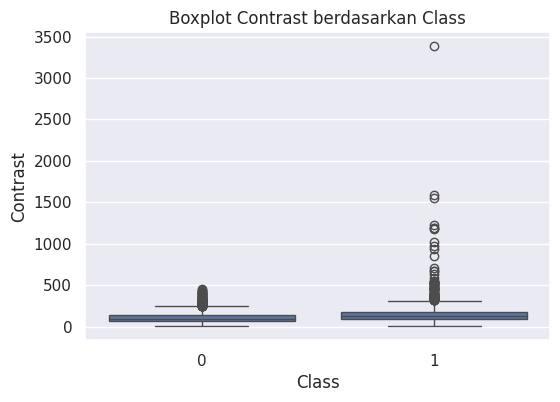

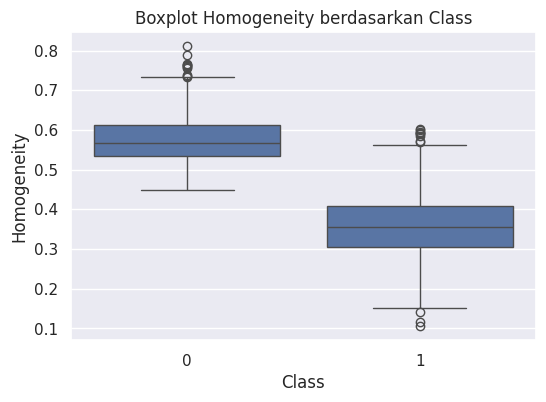

In [ ]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=feature, data=df_clean)
    plt.title(f"Boxplot {feature} berdasarkan Class")
    plt.xlabel("Class")
    plt.ylabel(feature)

    plt.show()

#### f. Pairplot (Relasi antar fitur)
* Pairplot digunakan untuk melihat hubungan antar beberapa fitur sekaligus dalam bentuk scatter plot dan distribusi.

* Melalui grafik ini, dapat terlihat pola pemisahan antar kelas berdasarkan kombinasi beberapa fitur. Hal ini membantu dalam memahami bagaimana fitur bekerja secara bersamaan dalam membedakan data.

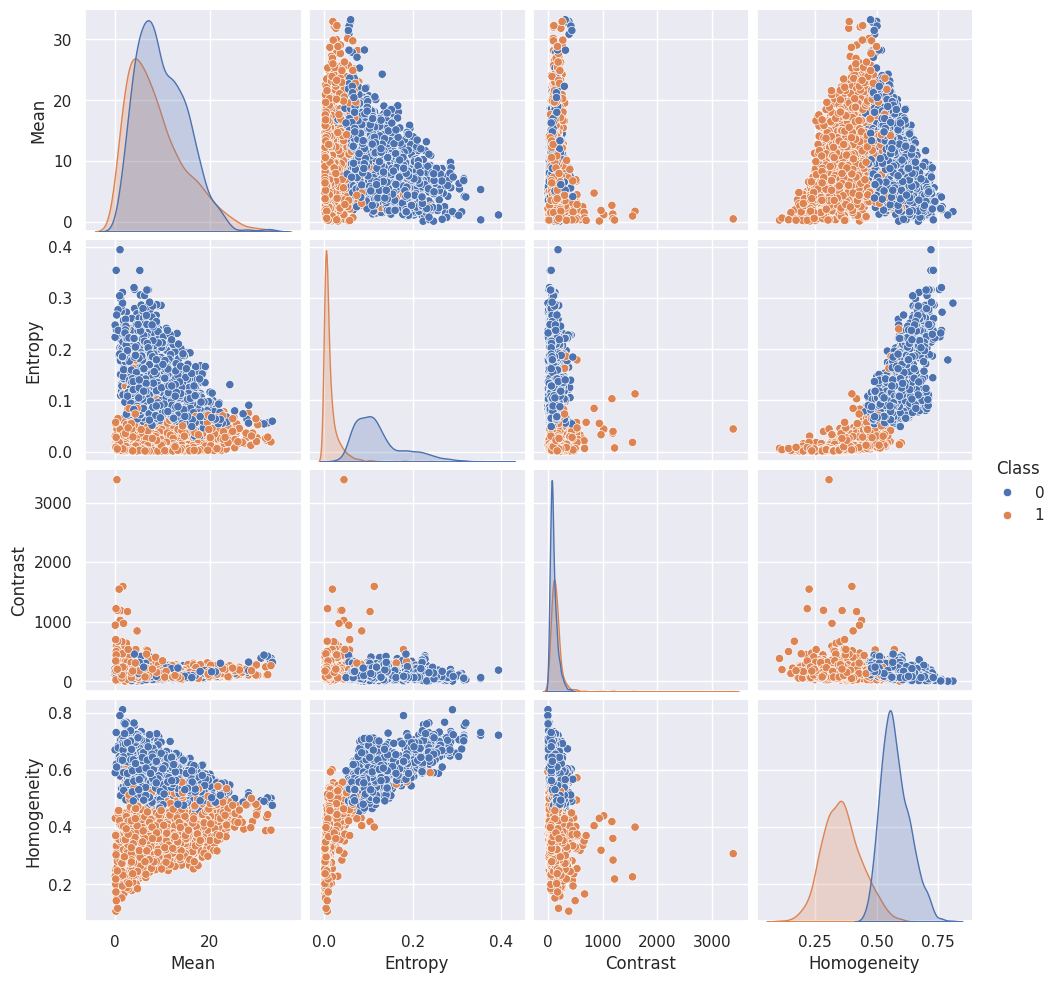

In [ ]:
# Pairplot agak berat, jadi pakai sebagian fitur saja
selected_features = ['Mean', 'Entropy', 'Contrast', 'Homogeneity', 'Class']
sns.pairplot(df_clean[selected_features], hue='Class')

plt.show()



---



## 6. Split Data (Training dan Testing)

Pada tahap ini dataset dibagi menjadi dua bagian, yaitu data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model. Pembagian dilakukan dengan perbandingan 80% untuk training dan 20% untuk testing. Selain itu, digunakan parameter stratify agar proporsi data pada masing-masing kelas tetap seimbang. Setelah proses split, ditampilkan jumlah data, distribusi kelas, serta contoh data untuk memastikan pembagian telah dilakukan dengan benar.

In [ ]:
# Membagi dataset menjadi data latih (training) dan data uji (testing)
# Training = untuk melatih model
# Testing = untuk menguji performa model

from sklearn.model_selection import train_test_split

# Melakukan split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% data untuk testing
    random_state=42,    # agar hasil selalu sama (reproducible)
    stratify=y          # menjaga proporsi kelas tetap seimbang
)

- Informasi Split Data

In [ ]:
# Menampilkan informasi Hasil Split
print("=== INFORMASI SPLIT DATA ===")

print("\nJumlah total data:", len(X_scaled))
print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

print("\nShape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

=== INFORMASI SPLIT DATA ===

Jumlah total data: 3699
Jumlah data training: 2959
Jumlah data testing: 740

Shape X_train: (2959, 13)
Shape X_test : (740, 13)


- Distribusi Class Pada Data Latih dan Data Test


In [ ]:
# Cek Distribusi Kelas Setelah Split
print("\n=== DISTRIBUSI CLASS PADA TRAINING DATA ===")
print(y_train.value_counts())

print("\n=== DISTRIBUSI CLASS PADA TESTING DATA ===")
print(y_test.value_counts())


=== DISTRIBUSI CLASS PADA TRAINING DATA ===
Class
0    1622
1    1337
Name: count, dtype: int64

=== DISTRIBUSI CLASS PADA TESTING DATA ===
Class
0    406
1    334
Name: count, dtype: int64


- Visualisasi Distribusi Class Training dan Testing

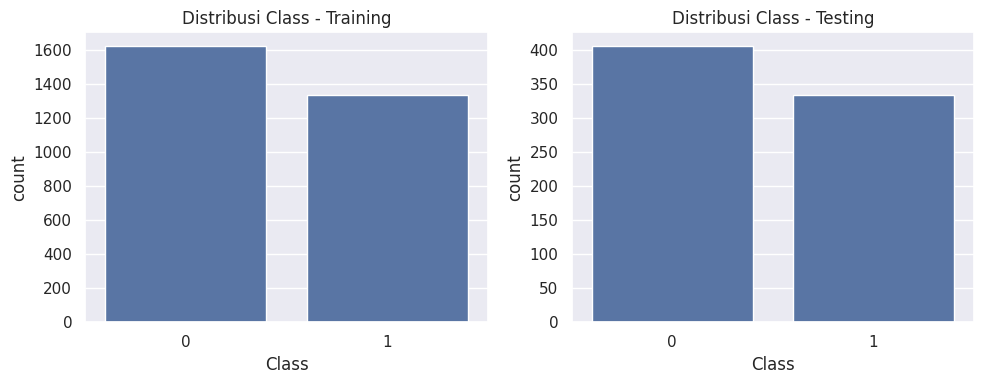

In [ ]:
# Visualisasi Distribusi Setelah Split
plt.figure(figsize=(10,4))

# Training
plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Distribusi Class - Training")

# Testing
plt.subplot(1,2,2)
sns.countplot(x=y_test)
plt.title("Distribusi Class - Testing")

plt.tight_layout()
plt.show()

- Sampel Data Training dan Testing


In [ ]:
# Menampilkan Sampel Data
print("\n=== SAMPLE DATA TRAINING ===")
display(X_train.head())

print("\n=== SAMPLE DATA TESTING ===")
display(X_test.head())


=== SAMPLE DATA TRAINING ===


,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
1874,0.319516,-0.321543,-0.170958,0.737150,-0.599170,-0.308432,-0.681809,0.861378,0.706452,0.689595,-0.861761,0.807880,-1.142698e-168
808,-1.143878,-1.121955,-1.314468,1.005395,0.306748,-0.005943,0.570005,1.042433,0.969523,1.289284,-0.372785,-1.620809,-1.142698e-168
2310,-0.352319,-0.380967,-0.238694,0.475883,-0.244404,-0.213704,-0.313655,0.661944,0.438472,0.512163,-0.202573,0.621778,-1.142698e-168
823,-1.571103,-1.331213,-1.799380,-0.409016,6.614142,7.689822,29.544790,-0.168642,-0.431868,-1.340497,12.456646,-7.600724,-1.142698e-168
2636,-0.585514,-0.672940,-0.600745,0.028304,-0.190895,-0.196766,0.597075,0.280213,-0.010742,0.428806,0.180089,-1.452517,-1.142698e-168



=== SAMPLE DATA TESTING ===


,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
408,0.089824,1.007430,1.048822,-0.846705,-0.091926,-0.156896,0.717979,-0.805273,-0.830688,-0.720048,0.399711,-0.118084,-1.142698e-168
1689,0.911637,0.108640,0.276146,0.509828,-0.700654,-0.331764,-0.454167,0.689324,0.473910,0.510689,-0.565842,0.574957,-1.142698e-168
553,-0.922918,-1.086269,-1.246198,2.152527,-0.126268,-0.172502,-0.910895,1.762996,2.203087,1.527189,-1.420722,1.022721,-1.142698e-168
3561,-0.974772,-0.593286,-0.496479,-1.011442,0.679114,0.202301,-0.315173,-1.272119,-0.975185,-1.071624,0.148670,-0.684741,9.961347e-168
1680,0.723722,0.278152,0.435738,0.146774,-0.607713,-0.312736,0.198076,0.390163,0.110063,0.391566,-0.172101,-0.212384,-1.142698e-168


#### Analisis Hasil Split Data :

Berdasarkan hasil pembagian data, dataset telah berhasil dibagi menjadi data training dan data testing dengan perbandingan 80% dan 20%. Jumlah data pada masing-masing bagian dapat dilihat dari output yang ditampilkan.

Distribusi kelas pada data training dan testing juga tetap seimbang karena menggunakan parameter *stratify*. Hal ini penting agar model tidak bias terhadap salah satu kelas.

Dengan pembagian ini, model dapat dilatih menggunakan data training dan kemudian diuji menggunakan data testing untuk mengetahui performanya terhadap data yang belum pernah dilihat sebelumnya.

---



## 7. Pembuatan dan Pelatihan Model Naive Bayes
Pada tahap ini dilakukan proses pembuatan dan pelatihan model Machine Learning menggunakan algoritma **Naive Bayes**, khususnya Gaussian Naive Bayes yang cocok untuk data numerik.

Model ini bekerja berdasarkan probabilitas dengan asumsi bahwa setiap fitur bersifat independen. Meskipun sederhana, metode ini cukup efektif untuk klasifikasi.

Proses yang dilakukan meliputi:
- Inisialisasi model
- Pelatihan model menggunakan data training
- Mempersiapkan model untuk melakukan prediksi

Tahap ini merupakan inti dari proses Machine Learning, dimana model mulai belajar pola dari data.

a. Inisialisasi Model

In [ ]:
# Membuat objek model Gaussian Naive Bayes
# Model ini cocok untuk data numerik (continuous)
model_nb = GaussianNB()

print("Model berhasil dibuat:")
print(model_nb)

Model berhasil dibuat:
GaussianNB()


b. Proses Training Model

In [ ]:
# Melatih model menggunakan data training
# Model akan belajar pola dari X_train dan y_train
model_nb.fit(X_train, y_train)

print("\nModel berhasil dilatih!")


Model berhasil dilatih!


c. Menampilkan Parameter Model

In [ ]:
# Menampilkan parameter model
print("\nParameter Model:")
print(model_nb.get_params())


Parameter Model:
{'priors': None, 'var_smoothing': 1e-09}


d. Menampilkan Informasi Distribusi Data

In [ ]:
# Mean tiap fitur per kelas
print("\nMean tiap fitur per kelas:")
print(model_nb.theta_)

# Variance tiap fitur per kelas
print("\nVariance tiap fitur per kelas:")
print(model_nb.var_)


Mean tiap fitur per kelas:
[[ 8.47051723e-002 -2.81452348e-001 -2.60097227e-001  7.22819559e-001
  -3.72421114e-001 -2.25949570e-001 -1.96374206e-001  7.92780306e-001
   7.05734887e-001  7.77323426e-001 -5.13234321e-001  1.07923127e-001
  -3.84416786e-169]
 [-1.09224017e-001  3.57677532e-001  3.31808277e-001 -8.62808307e-001
   4.53421676e-001  2.68868879e-001  2.41047571e-001 -9.56485505e-001
  -8.40726839e-001 -9.46210765e-001  6.25347291e-001 -9.02520969e-002
   5.19926248e-169]]

Variance tiap fitur per kelas:
[[8.25320830e-01 5.80536126e-01 7.15718156e-01 6.70781529e-01
  1.90102019e-01 7.67344782e-02 3.79394221e-01 3.27401465e-01
  7.35198677e-01 2.09106364e-01 4.11917988e-01 5.09243240e-01
  1.08802571e-09]
 [1.14314401e+00 1.29336736e+00 1.15792822e+00 7.71872993e-02
  1.55738720e+00 1.75675330e+00 1.84282839e+00 1.75728609e-01
  6.97422970e-02 3.66992083e-01 1.09773341e+00 1.30705009e+00
  1.08802571e-09]]


#### Penjelasan Model :

Setelah dilakukan pelatihan, model Naive Bayes akan menyimpan informasi statistik dari setiap fitur, seperti nilai rata-rata (mean) dan variansi (variance) untuk masing-masing kelas.

Informasi ini digunakan oleh model untuk menghitung probabilitas suatu data termasuk ke dalam kelas tertentu saat proses prediksi dilakukan.

---



## 8. Melakukan Prediksi
Pada tahap ini model yang telah dilatih digunakan untuk melakukan prediksi terhadap data testing.

Proses prediksi bertujuan untuk mengetahui kemampuan model dalam mengklasifikasikan data baru yang belum pernah dilihat sebelumnya. Hasil prediksi akan berupa label kelas, yaitu 0 (tidak tumor) dan 1 (tumor).

Selain itu, model juga menghasilkan probabilitas prediksi yang menunjukkan tingkat keyakinan model terhadap hasil klasifikasi.

- Prediksi Label

In [ ]:
# Model akan memprediksi class dari data testing
y_pred = model_nb.predict(X_test)

print("Hasil prediksi (5 data pertama):")
print(y_pred[:5])

Hasil prediksi (5 data pertama):
[1 0 0 1 0]


- Prediksi Probabilitas

In [ ]:
# Model juga bisa memberikan probabilitas tiap kelas
# [:,1] artinya kita ambil probabilitas untuk kelas 1 (tumor)
y_prob = model_nb.predict_proba(X_test)[:,1]

print("\nProbabilitas prediksi (5 data pertama):")
print(y_prob[:5])


Probabilitas prediksi (5 data pertama):
[9.99999065e-01 1.78384340e-17 5.92660725e-67 9.99999998e-01
 2.20767543e-10]


- Membandingkan Hasil Prediksi dengan Data Asli

In [ ]:
# Membuat DataFrame untuk melihat perbandingan
hasil_prediksi = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

print("\nPerbandingan hasil (10 data pertama):")
display(hasil_prediksi.head(10))


Perbandingan hasil (10 data pertama):


,Actual,Predicted,Probability
0,1,1,9.999991e-01
1,0,0,1.783843e-17
2,0,0,5.926607e-67
3,1,1,1.000000e+00
4,0,0,2.207675e-10
5,0,0,9.715902e-09
6,0,0,3.798063e-15
7,0,0,1.848382e-10
8,0,0,8.497136e-43
9,1,1,9.999997e-01


#### Analisis Hasil Prediksi :
Dari hasil prediksi dapat dilihat perbandingan antara nilai aktual dan hasil prediksi model. Selain itu, ditampilkan juga nilai probabilitas yang menunjukkan tingkat keyakinan model dalam menentukan kelas.

Semakin tinggi nilai probabilitas, maka semakin yakin model terhadap hasil prediksinya. Hasil ini menjadi dasar untuk melakukan evaluasi lebih lanjut terhadap performa model.

---



## 9. Evaluasi Model Naive Bayes
Pada tahap ini dilakukan evaluasi terhadap model Naive Bayes yang telah dilatih. Evaluasi bertujuan untuk mengetahui seberapa baik model dalam melakukan klasifikasi data.

Beberapa metode evaluasi yang digunakan antara lain:
- Accuracy untuk mengukur tingkat keakuratan model
- Confusion Matrix untuk melihat hasil klasifikasi secara detail
- Classification Report untuk melihat precision, recall, dan f1-score
- ROC Curve dan AUC untuk mengukur performa model secara keseluruhan

Hasil evaluasi ini akan digunakan untuk menilai performa model dalam mengklasifikasikan citra tumor otak.

#### a. Menghitung Akurasi (Accuracy)
Accuracy digunakan untuk mengukur seberapa banyak prediksi yang benar dibandingkan dengan total data. Semakin tinggi nilai accuracy, maka semakin baik performa model dalam melakukan klasifikasi.

In [ ]:
# Menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)

print("=== HASIL EVALUASI MODEL ===")
print("Accuracy:", round(accuracy, 4))

=== HASIL EVALUASI MODEL ===
Accuracy: 0.9527


#### b. Confusion Matrix
Confusion Matrix digunakan untuk melihat hasil klasifikasi secara lebih detail, yaitu jumlah prediksi benar dan salah pada masing-masing kelas.

Melalui matrix ini dapat diketahui:
- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

Sehingga dapat dianalisis kesalahan yang dilakukan oleh model.

In [ ]:
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[403   3]
 [ 32 302]]


Visualisasi Confusion Matrix :

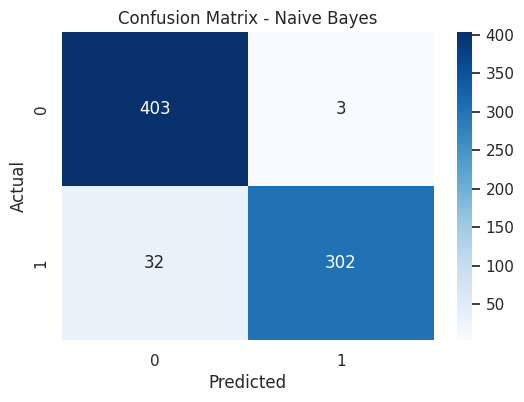

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### d. Classification Report
Classification Report menampilkan metrik evaluasi seperti precision, recall, dan f1-score.

- Precision menunjukkan ketepatan prediksi
- Recall menunjukkan kemampuan model menemukan data yang benar
- F1-score adalah kombinasi dari precision dan recall

Metrik ini memberikan gambaran performa model secara lebih detail dibandingkan accuracy.

In [ ]:
# Menampilkan precision, recall, f1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       406
           1       0.99      0.90      0.95       334

    accuracy                           0.95       740
   macro avg       0.96      0.95      0.95       740
weighted avg       0.96      0.95      0.95       740



#### e. ROC Curve dan AUC
ROC Curve digunakan untuk mengukur kemampuan model dalam membedakan antara kelas.

Nilai AUC (Area Under Curve) menunjukkan kualitas model:
- Semakin mendekati 1 → model semakin baik
- Semakin mendekati 0.5 → model kurang baik

ROC Curve memberikan gambaran performa model secara keseluruhan.

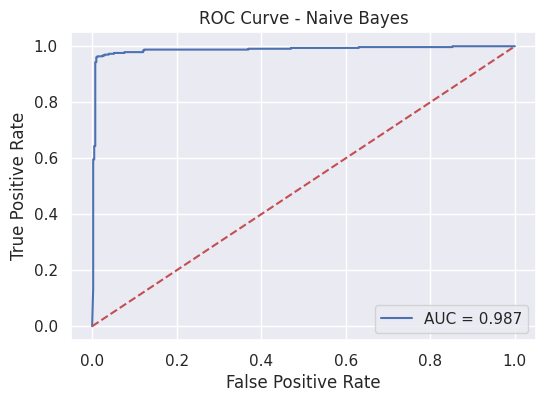

In [ ]:
# Menghitung ROC Curve
fpr, tpr, threshold = roc_curve(y_test, y_prob)

# Menghitung AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()

plt.show()

#### f. Cross Validation
Cross Validation digunakan untuk menguji kestabilan model dengan membagi data menjadi beberapa bagian dan melakukan pengujian secara bergantian.

Metode ini membantu memastikan bahwa model tidak hanya bagus pada satu pembagian data saja, tetapi konsisten pada berbagai kondisi.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_nb, X_scaled, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Rata-rata Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.95675676 0.95540541 0.98648649 0.96756757 0.96752368]
Rata-rata Accuracy: 0.9667479793731484




---



---


## Kesimpulan :



Berdasarkan hasil implementasi dan evaluasi, model Naive Bayes menunjukkan performa yang cukup baik dalam mengklasifikasikan citra tumor otak. Nilai accuracy yang diperoleh menunjukkan bahwa model mampu mengenali pola data dengan cukup efektif.

Penggunaan teknik preprocessing seperti normalisasi data membantu meningkatkan kinerja model, serta menjaga kestabilan dalam proses pelatihan. Selain itu, hasil visualisasi menunjukkan adanya perbedaan pola antara kelas tumor dan tidak tumor yang mendukung proses klasifikasi.

Meskipun sederhana, Naive Bayes memiliki keunggulan dalam kecepatan dan efisiensi, sehingga cocok digunakan sebagai model baseline. Untuk pengembangan lebih lanjut, dapat dilakukan perbandingan dengan metode lain guna meningkatkan performa klasifikasi.

---

